Notebook for evaluating validation peformance

In [9]:
"""
Evaluation script for a trained U-Net segmentation model.

The script evaluates one selected model on the validation dataset and reports
pixel-wise segmentation metrics, droplet diameter statistics, DSD errors,
phase fraction estimates, model size, and training time. It also visualizes one
selected validation case to compare the ground truth mask, raw prediction, and
post-processed prediction.
"""

'\nEvaluation script for a trained U-Net segmentation model.\n\nThe script evaluates one selected model on the validation dataset and reports\npixel-wise segmentation metrics, droplet diameter statistics, DSD errors,\nphase fraction estimates, model size, and training time. It also visualizes one\nselected validation case to compare the ground truth mask, raw prediction, and\npost-processed prediction.\n'

In [25]:
from pathlib import Path
import csv
import os

import numpy as np
import pandas as pd
from PIL import Image

from src.model import load_model
from src.evaluation import (
    evaluate_dataset,
    plot_compare_masks_version2,
    plot_compare_masks,
    plot_mask_venn,
    plot_histogram,
    predict_full_image,
)
from src.mask_analysis import diameter_error_stats
from src.dataset import VAL_INPUT_DIR, VAL_MASK_DIR


In [11]:

BASE_DIR = Path.cwd()

MODEL_RUNS = {
    "Spatially Augmented Dataset": BASE_DIR / "Latest_Models" / "NORMAL_no_aug",
    "Original Dataset": BASE_DIR / "Latest_Models" / "som orginaldatasett" / "u_net_no_aug",
    "No Pretraining": BASE_DIR / "Latest_Models" / "no_aug_no_weights",
    "PolyS Pretraining": BASE_DIR / "Latest_Models" / "PS_no_aug",
    "Million Bubble Pretraining": BASE_DIR / "Latest_Models" / "MB_no_aug",
    "More Intense Augmentations": BASE_DIR / "Latest_Models" / "different aug stratergies" / "aug_olf_full_no_dropout_no_shift",
    "Less Intense Augmentations": BASE_DIR / "Latest_Models" / "different aug stratergies" / "aug_light_full",
}

Loading model from last training

In [12]:
final_model_path = MODEL_RUNS["Spatially Augmented Dataset"] / "best_model.pth" #<-- Change this to the path of your trained model  

final_model = load_model(final_model_path)


eval_df, gt_d, raw_d, post_d, masks = evaluate_dataset(
    model=final_model,
    input_dir=VAL_INPUT_DIR,
    mask_dir=VAL_MASK_DIR,
)


Metrics stats

In [13]:
metric_cols = [
    "dice_raw", "dice_post",
    "iou_raw", "iou_post",
    "precision_raw", "precision_post",
    "recall_raw", "recall_post",
    #"pixel_acc_raw", "pixel_acc_post",
]

summary = eval_df[metric_cols].agg(["mean", "min", "max"]).T
summary

,mean,min,max
dice_raw,0.715549,0.494765,0.886269
dice_post,0.714594,0.486220,0.891424
iou_raw,0.565446,0.328696,0.795766
iou_post,0.564531,0.321196,0.804116
precision_raw,0.716511,0.464608,0.916065
precision_post,0.716122,0.451339,0.926162
recall_raw,0.730457,0.381147,0.928416
recall_post,0.728963,0.373761,0.929718


In [14]:
eval_df["dice_difference"] = eval_df["dice_raw"] - eval_df["dice_post"]
#here count is the number of images in the validation set.   
print(eval_df[["image", "dice_raw", "dice_post", "dice_difference"]].sort_values(by="dice_difference", ascending=False).head(10)) 

                    image  dice_raw  dice_post  dice_difference
35     212_tile_0_256.tif  0.726023   0.682327         0.043695
32  211_tile_1024_512.tif  0.556319   0.537778         0.018541
40   214_tile_512_256.tif  0.638581   0.620703         0.017877
69   262_tile_256_256.tif  0.880366   0.868284         0.012083
31    211_tile_1024_0.tif  0.605185   0.593200         0.011986
25   206_tile_512_512.tif  0.703825   0.693585         0.010239
70   262_tile_512_512.tif  0.604439   0.595890         0.008549
34       212_tile_0_0.tif  0.494765   0.486220         0.008545
73     263_tile_0_512.tif  0.827524   0.820814         0.006709
45   219_tile_256_512.tif  0.772542   0.767262         0.005280


Compare Masks

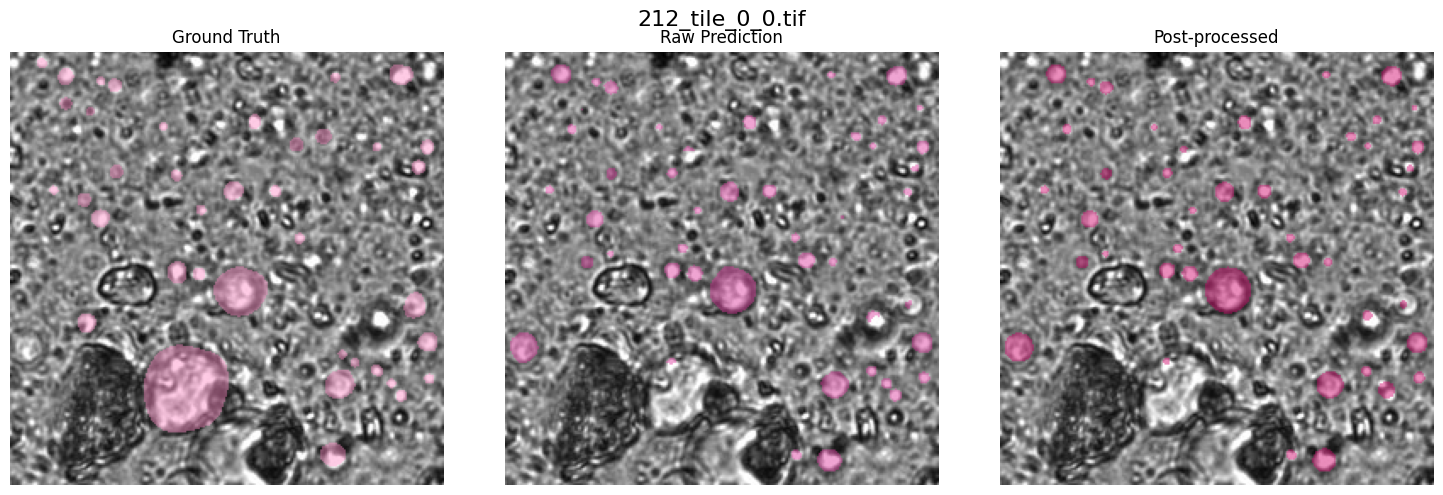

In [15]:
img_name = list(masks.keys())[34] 
org_img = np.array(Image.open(val_input_dir / img_name).convert("L"))
gt_mask = masks[img_name]["gt"]
raw_mask = masks[img_name]["raw"]
post_mask = masks[img_name]["post"]

plot_compare_masks_version2(org_img, gt_mask, raw_mask, post_mask, title=img_name)

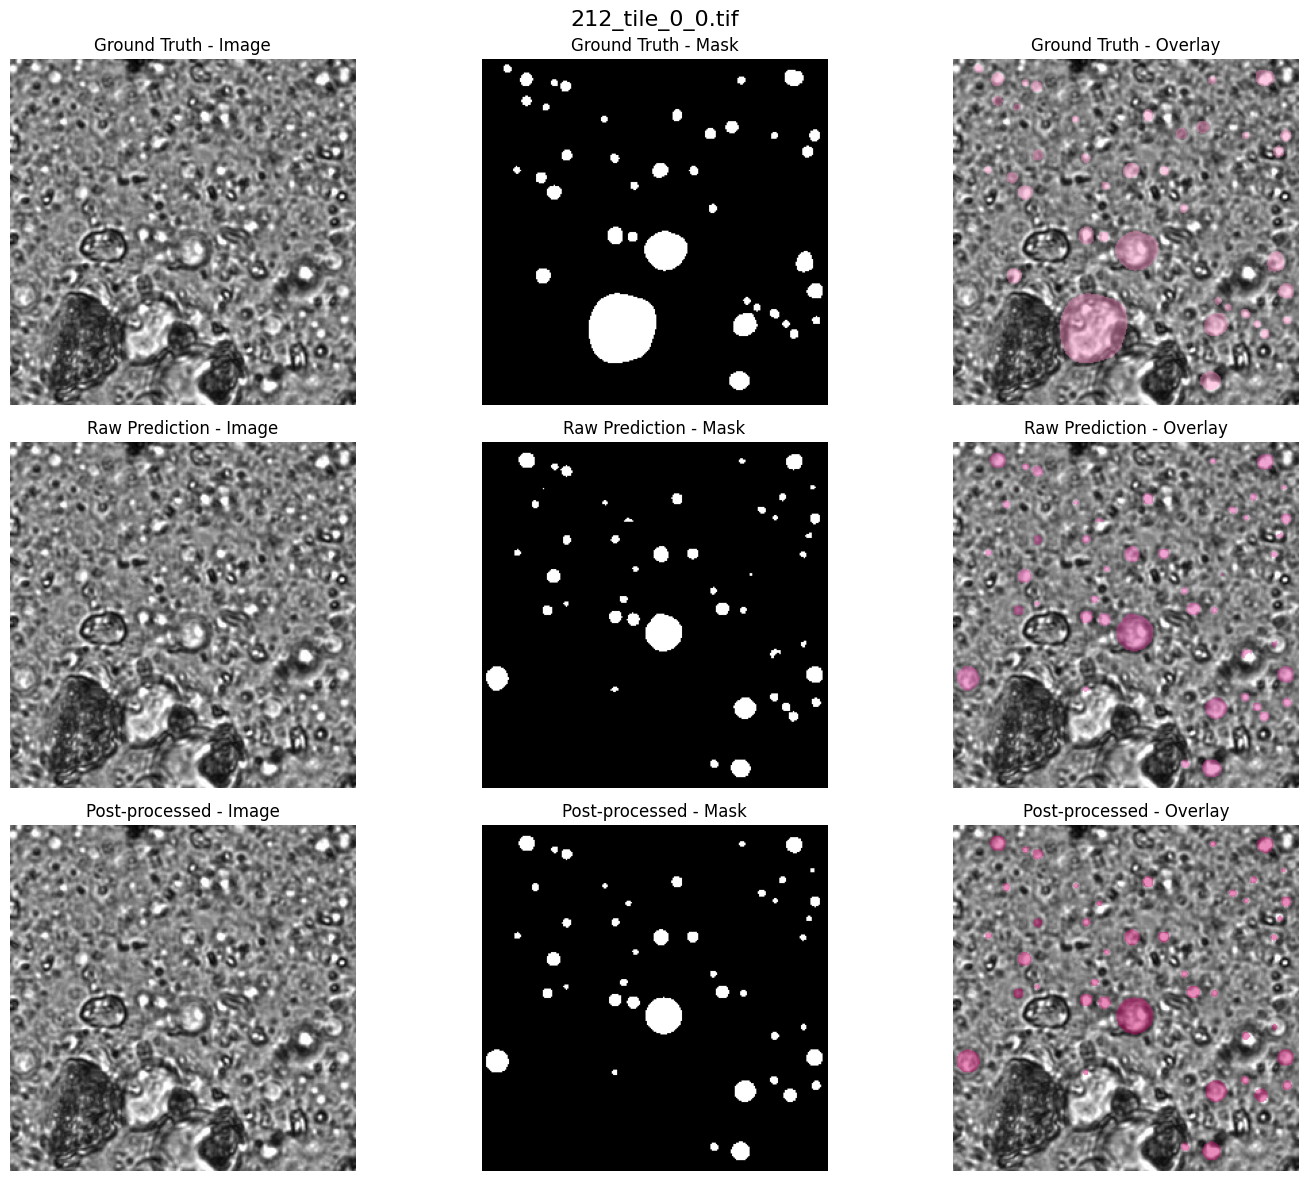

In [18]:

plot_compare_masks(org_img, gt_mask, raw_mask, post_mask, title=img_name)

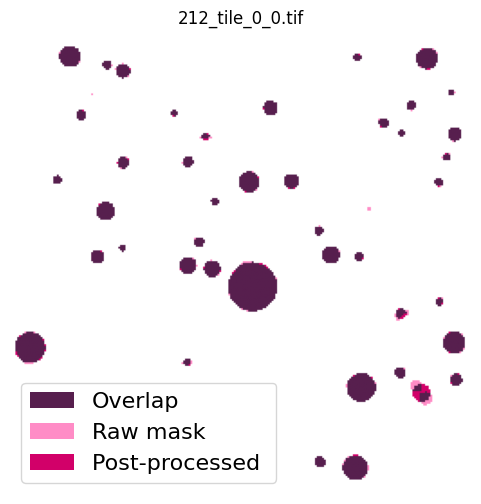

In [22]:
plot_mask_venn(raw_mask, post_mask, title=img_name, al=True , loc_text = "lower left")

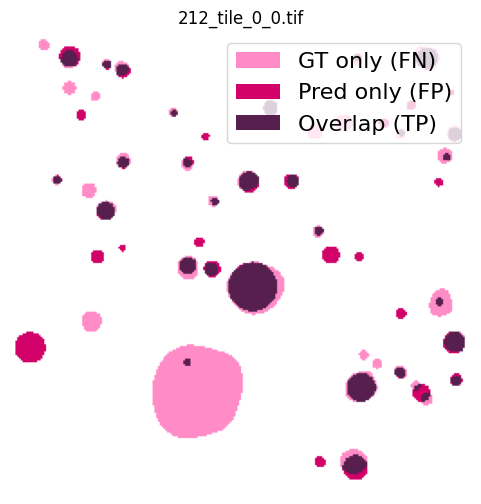

In [20]:
plot_mask_venn(gt_mask, post_mask, title=img_name, al=False)

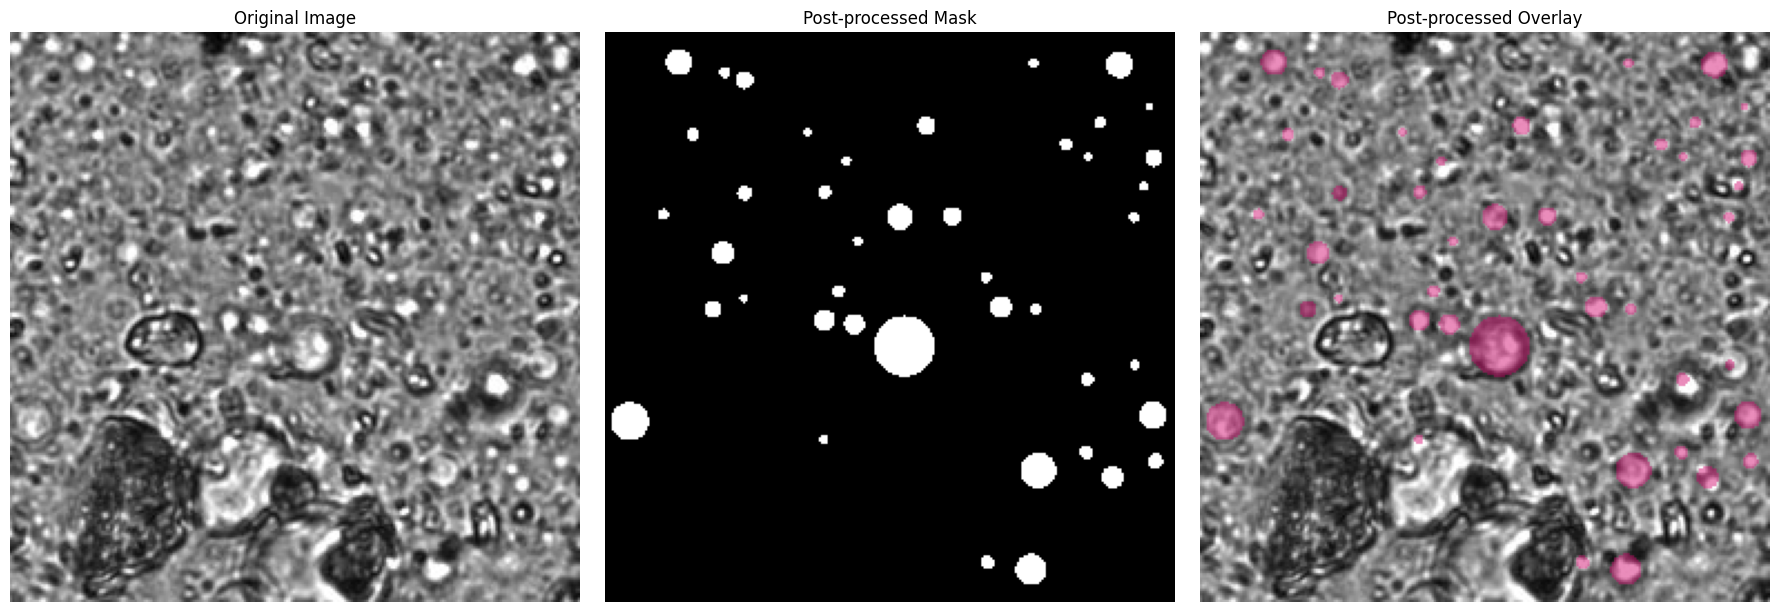

In [26]:
p = predict_full_image(final_model, VAL_INPUT_DIR / img_name, postprocess=True)

Droplet size distribution

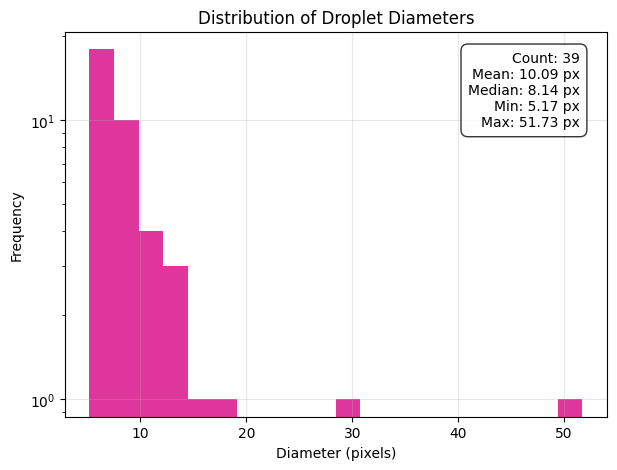

In [ ]:
plot_histogram(gt_mask)


Global diameter stats

In [27]:
eval_df["error_mean"] = eval_df["raw_mean_diameter"] - eval_df["gt_mean_diameter"]
eval_df["mse_mean"] = eval_df["error_mean"]**2
cols = [
    "image",
    "gt_mean_diameter", "raw_mean_diameter",
    "gt_median_diameter", "raw_median_diameter",
    "gt_min_diameter", "raw_min_diameter",
    "gt_max_diameter", "raw_max_diameter",
    "mse_mean"
]

top5 = eval_df.sort_values("mse_mean").head(5)

print("Top 5 best cases (lowest diameter error):")
display(top5[cols])

bottom5 = eval_df.sort_values("mse_mean", ascending=False).head(5)

print("Bottom 5 worst cases (highest diameter error):")
display(bottom5[cols])

Top 5 best cases (lowest diameter error):


,image,gt_mean_diameter,raw_mean_diameter,gt_median_diameter,raw_median_diameter,gt_min_diameter,raw_min_diameter,gt_max_diameter,raw_max_diameter,mse_mean
46,220_tile_0_768.tif,8.05083,8.03924,7.31273,7.08478,5.17088,3.74241,19.21560,19.01578,0.000134
79,263_tile_768_0.tif,8.03708,8.06887,6.28255,6.18039,5.17088,4.06843,16.88803,17.94797,0.001011
43,218_tile_512_256.tif,16.01985,15.97527,7.48046,10.46416,5.29257,4.78731,68.55310,68.85887,0.001987
49,220_tile_256_768.tif,8.06217,7.98974,7.13594,7.17754,5.17088,3.74241,16.39065,18.40331,0.005246
45,219_tile_256_512.tif,9.37490,9.26769,8.29186,7.81764,5.41152,3.74241,22.25512,23.53421,0.011494


Bottom 5 worst cases (highest diameter error):


,image,gt_mean_diameter,raw_mean_diameter,gt_median_diameter,raw_median_diameter,gt_min_diameter,raw_min_diameter,gt_max_diameter,raw_max_diameter,mse_mean
66,258_tile_0_512.tif,15.05171,11.55031,9.90149,7.04673,5.41152,3.90882,27.38500,28.74600,12.259802
41,214_tile_768_0.tif,12.99387,9.75791,11.99484,7.13650,5.52791,4.51352,29.27269,30.06659,10.471437
75,263_tile_256_0.tif,9.03548,12.14772,6.57881,6.48204,5.29257,4.65243,30.77808,36.45905,9.686038
35,212_tile_0_256.tif,13.48121,16.53434,9.13214,9.96476,5.29257,5.04627,44.68154,54.57204,9.321603
39,214_tile_512_0.tif,12.92979,10.32206,8.51908,7.04673,5.17088,3.74241,44.46730,48.01913,6.800256


In [28]:
print(f"Global errors between GT and Raw Predictions: {diameter_error_stats(gt_d, raw_d)}")
print(f"Global errors between GT and Post Predictions: {diameter_error_stats(gt_d, post_d)}")


Global errors between GT and Raw Predictions: {'mse': 12.62432, 'rmse': 3.55307, 'mae': 1.71742, 'bias': -1.71742, 'std': 3.11043}
Global errors between GT and Post Predictions: {'mse': 10.18377, 'rmse': 3.1912, 'mae': 1.47708, 'bias': -1.47708, 'std': 2.82878}


Oil to Water ratio

In [29]:
#eval_df.columns

eval_df[["gt_water_oil_ratio", "raw_water_oil_ratio", "post_water_oil_ratio"]].describe()



,gt_water_oil_ratio,raw_water_oil_ratio,post_water_oil_ratio
count,80.000000,80.000000,80.000000
mean,0.050895,0.052702,0.052732
std,0.033868,0.035436,0.035728
min,0.009318,0.006373,0.006373
25%,0.028855,0.031288,0.031081
50%,0.044282,0.044831,0.044623
75%,0.063292,0.065423,0.065518
max,0.236948,0.216107,0.218526


Other parameters to evaluate model on

In [30]:
import os
run_name = final_model_path.parent.name

tr_path = Path(
    r"C:\Users\47469\master_enviorment\FinalModel\runs\training_runs.csv"
)

with open(tr_path, mode='r', newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["run_name"] == run_name:

            total_training_time = float(row["total_training_time_sec"])
            mean_epoch_time = float(row["mean_epoch_time_sec"])

            print(f"Run: {run_name}")
            print(f"Total training time: {total_training_time:.2f} sec")
            print(f"Mean epoch time: {mean_epoch_time:.2f} sec")

            break
        
size_mb = os.path.getsize(final_model_path) / (1024 ** 2)

print(f"Model size: {size_mb:.2f} MB")

num_params = sum(p.numel() for p in final_model.parameters())
trainable_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)

print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Run: NORMAL_no_aug
Total training time: 10297.30 sec
Mean epoch time: 935.66 sec
Model size: 279.85 MB
Total parameters: 24,430,097
Trainable parameters: 24,430,097
